In [75]:
import numpy as np
import math
import pandas as pd
from pathlib import Path
from joblib import Parallel, delayed
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

PAPER_DIR = Path(r"E:\PAPER")

code_dir = PAPER_DIR / "code"
data_dir = PAPER_DIR / "data"
fig_dir = PAPER_DIR / "figures"
paper_dir = PAPER_DIR / "paper"

data_generation_code_dir = code_dir / "data_generation"
plotting_code_dir = code_dir / "plotting"

kerr_data_dir = data_dir / "kerr"
kerr_data_error_analysis_dir = data_dir / "error_analysis"
kerr_critical_curves_data_dir = kerr_data_dir / "critical_curves"
kerr_critical_quantities_data_dir = kerr_data_dir / "critical_quantities"
kerr_trajectories_data_dir = kerr_data_dir / "trajectories"
kerr_critical_trajectories_data_dir = kerr_data_dir / "critical_trajectories"
kerr_critical_curves_data_dir_ivp = kerr_critical_curves_data_dir / "IVP"

quasi_kerr_data_dir = data_dir / "quasi_kerr"
quasi_kerr_critical_curves_data_dir = quasi_kerr_data_dir / "critical_curves"
quasi_kerr_critical_quantities_data_dir = quasi_kerr_data_dir / "critical_quantities"
quasi_kerr_trajectories_data_dir = quasi_kerr_data_dir / "trajectories"
quasi_kerr_critical_trajectories_data_dir = quasi_kerr_data_dir / "critical_trajectories"
qk_testing_data_dir = quasi_kerr_data_dir / "testing"

kerr_fig_dir = fig_dir / "kerr"
quasi_kerr_fig_dir = fig_dir / "quasi_kerr"
kerr_fig_r_t = kerr_fig_dir / "R(t)"
kerr_fig_critical_curve = kerr_fig_dir / "Critical_Curves"

paper_drafts_dir = paper_dir / "drafts"
paper_figure_dir = paper_dir / "final_figures"

In [77]:
def filename_tag(metric, a, theta_obs_deg, ptheta0=None, epsilon_qk=None):

    tag = f"{metric}_a_{a:.2f}_inc_{theta_obs_deg:.1f}"
    
    # Only add epsilon for quasi-Kerr data
    if metric == 'quasi_kerr':
        tag += f"_eps_{epsilon_qk:+.2f}"
        
    # Only add ptheta for individual trajectory files
    if ptheta0 is not None:
        tag += f"_ptheta_{ptheta0:+.2f}"
    
    return tag

In [45]:
def kerr_xi(r, a):

    return (r**2 * (r - 3) + a**2 * (r + 1)) / (a * (1 - r))


def kerr_eta(r, a):

    return (r**3 * (4*a**2 - r*(r - 3)**2)) / ( a**2 * (1 - r)**2)

In [47]:
def analytic_kerr_critical_curve(a, theta_obs, n=2000):

    if np.isclose(a, 0.0):

        angle = np.linspace(0, 2*np.pi, n)

        alpha = 3*np.sqrt(3) * np.cos(angle)
        beta  = 3*np.sqrt(3) * np.sin(angle)

        return alpha, beta


    # --------------------------------------------------------
    # Kerr spherical photon orbit radii
    # --------------------------------------------------------

    r_ph_pro = 2 * (1 + np.cos((2/3) * np.arccos(-a)))

    r_ph_ret = 2 * (1 + np.cos((2/3) * np.arccos(a)))

    r = np.linspace(r_ph_pro, r_ph_ret, n)


    # --------------------------------------------------------
    # Constants of motion for spherical photon orbits (M=1)
    # --------------------------------------------------------

    xi = kerr_xi(r, a)

    eta = kerr_eta(r, a)

    # --------------------------------------------------------
    # Image plane coordinates
    # --------------------------------------------------------

    sin_th = np.sin(theta_obs)
    cos_th = np.cos(theta_obs)

    alpha = -xi / sin_th

    beta_sq = (eta + a**2 * cos_th**2 - xi**2 * cos_th**2 / sin_th**2)

    mask = beta_sq >= 0 # Keep only physically allowed points

    alpha = alpha[mask]
    beta = np.sqrt(beta_sq[mask])

    # Upper + lower halves
    alpha_full = np.concatenate([alpha, alpha[::-1]])

    beta_full = np.concatenate([beta, -beta[::-1]])

    alpha_full = np.append(alpha_full, alpha_full[0])
    beta_full = np.append(beta_full, beta_full[0])

    return alpha_full, beta_full

In [49]:
#Convert data in each sampling method to image plane points

def numerical_image_plane(df, sampling_method, theta_obs):

    if "status" in df.columns:

        df = df[df["status"] == "ok"].copy()  # Keep only successful critical points

    df = df[np.isfinite(df["ptheta"]) & np.isfinite(df["bcrit"])].copy()

    if sampling_method in ["fixed_ptheta", "fixed_b"]:

        df["alpha_num"] = (-df["bcrit"] / np.sin(theta_obs))

        df["beta_num"] = df["ptheta"]


    elif sampling_method == "fixed_psi":

        df["alpha_num"] = df["alpha"]
        df["beta_num"] = df["beta"]


    else:

        raise ValueError("Unknown sampling method")
        
    df["screen_angle_deg"] = np.degrees(np.arctan2(df["beta_num"], df["alpha_num"])) % 360

    return df

In [81]:
def plot_kerr_validation(a, theta_obs_deg):

    theta_obs = np.deg2rad(theta_obs_deg)

    # --------------------------------------------------------
    # Files
    # --------------------------------------------------------

    tag = filename_tag(metric="kerr", a=a, theta_obs_deg=theta_obs_deg)

    fixed_ptheta_file = (kerr_critical_curves_data_dir/ f"Critical_Curve_fixed_ptheta_{tag}.csv")

    fixed_b_file = (kerr_critical_curves_data_dir / f"Critical_Curve_fixed_b_{tag}.csv")

    fixed_psi_file = (kerr_critical_curves_data_dir / f"Critical_Curve_fixed_psi_{tag}.csv")

    # --------------------------------------------------------
    # Load data
    # --------------------------------------------------------

    df_ptheta = pd.read_csv(fixed_ptheta_file)
    df_b      = pd.read_csv(fixed_b_file)
    df_rho    = pd.read_csv(fixed_psi_file)

    # --------------------------------------------------------
    # Numerical image-plane coordinates
    # --------------------------------------------------------

    df_ptheta = numerical_image_plane(df_ptheta, "fixed_ptheta", theta_obs)
    df_b = numerical_image_plane(df_b, "fixed_b", theta_obs)
    df_rho = numerical_image_plane(df_rho, "fixed_psi", theta_obs)
    
    alpha_0 = df_ptheta["alpha_num"]
    beta_0 = df_ptheta["beta_num"]
    
    alpha_1 = df_b["alpha_num"]
    beta_1 = df_b["beta_num"]
    
    alpha_2 = df_rho["alpha_num"]
    beta_2 = df_rho["beta_num"]

    # --------------------------------------------------------
    # Analytic Kerr
    # --------------------------------------------------------

    alpha_K, beta_K = analytic_kerr_critical_curve(a, theta_obs)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.plot(alpha_K, beta_K, linewidth=2, label="Analytic Kerr")

    #ax.scatter(alpha_0, beta_0, s=35, marker="o", label=r"Fixed $p_\theta$")

    ax.scatter(alpha_1, beta_1, s=35, marker="s", label=r"Fixed $b$")

    #ax.scatter(alpha_2, beta_2, s=35, marker="D", label=r"Fixed $\psi$")


    ax.set_xlabel(r"$\alpha/M$")
    ax.set_ylabel(r"$\beta/M$")

    ax.set_title(rf"Kerr: $a={a:.2f}$, "rf"$i={theta_obs_deg:.0f}^\circ$")

    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend()
    
    # --------------------------------------------------------
    # Save figure
    # --------------------------------------------------------
    
    fig_name = (f"Kerr_Validation_"f"a_{a:.2f}_"f"inc_{theta_obs_deg:.1f}")
    
    #fig.savefig(kerr_fig_critical_curve / f"{fig_name}.png", dpi=300, bbox_inches="tight")
    
    #fig.savefig(kerr_fig_critical_curve / f"{fig_name}.pdf", bbox_inches="tight")
    
    print("Saved:", fig_name)

    plt.show()

Saved: Kerr_Validation_a_0.98_inc_90.0


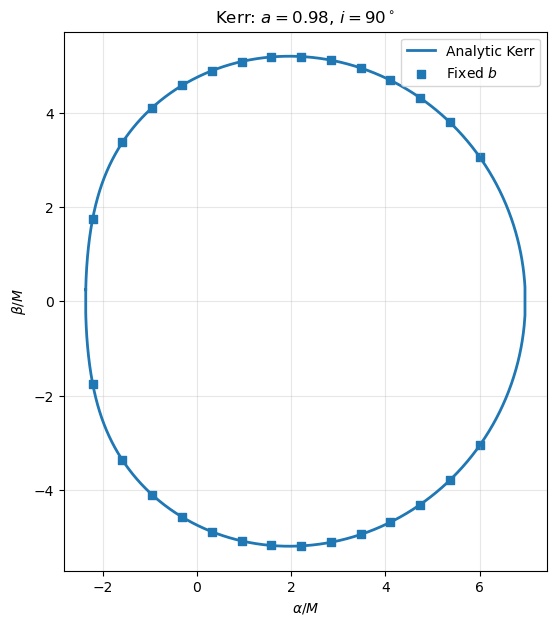

In [83]:
#Plot Kerr critical curve numerical vs analytic for different sampling methods
a = 0.98
theta_obs_deg = 90
plot_kerr_validation(a, theta_obs_deg)